# The p-Median Problem

## Learning Objectives

After reading this chapter, you should be able to:

1. Explain what the p-Median Problem（p-中位数问题）is and why it matters in spatial optimization（空间优化）.
2. Formulate the p-Median Problem using decision variables（决策变量）, an objective function（目标函数）, and constraints（约束条件）.
3. Solve a small p-Median Problem manually using a distance matrix（距离矩阵）.
4. Implement a simple p-Median solver in Python using brute-force search.
5. Interpret selected facility locations（设施位置）, assignments（分配关系）, and total weighted distance（总加权距离）.
6. Identify key limitations（局限性）of the p-Median model and explain how they motivate later improvements.

---

## Why This Topic Matters

Suppose a city wants to open three public clinics. There are many neighborhoods, but the city has a limited budget. It cannot build a clinic everywhere. The question is:

> Where should the clinics be located so that residents, on average, travel as little as possible?

This is a classic facility location problem（设施选址问题）. The same type of question appears in many fields:

- locating hospitals or clinics;
- placing fire stations or ambulance bases;
- choosing warehouse or distribution centers;
- locating public libraries, parks, or schools;
- placing electric vehicle charging stations;
- selecting emergency shelters after a disaster.

In all these examples, we have demand points（需求点）and candidate sites（候选位置）. Demand points are places that need service. Candidate sites are possible places where facilities can be located.

The p-Median Problem helps answer this question:

> If we can choose only $p$ facilities, which $p$ locations minimize the total weighted travel distance from demand points to their nearest facility?

The word “median” here does not simply mean the statistical median of a list. In spatial optimization, a median location is a location that minimizes total travel cost. The p-Median Problem generalizes this idea from one facility to $p$ facilities.

## Big Picture Intuition

The p-Median Problem is about **average efficiency**.

Imagine that every neighborhood sends its residents to the nearest selected clinic. If a neighborhood has more people, its travel distance matters more. The model therefore tries to minimize the total population-weighted travel distance.

In plain language:

> p-Median chooses facility locations so that the average user travels as little as possible.

This means the model tends to favor places close to large demand concentrations. If most residents live in the city center, p-Median may place facilities near the center. This is efficient, but it can create a problem: remote or low-population areas may remain far from service.

That is the first important trade-off:

> p-Median is usually efficient, but not always equitable.

---

## A Simple Workflow

```mermaid
flowchart LR
    A[Demand points] --> C[Distance matrix]
    B[Candidate sites] --> C
    C --> D[p-Median model]
    D --> E[Selected p facilities]
    E --> F[Assign demand to nearest facility]
    F --> G[Interpret total cost]
```

---

## Formal Definition and Core Equations

## Notation

| Symbol | Meaning |
|---|---|
| $i \in I$ | demand point index（需求点索引） |
| $j \in J$ | candidate site index（候选位置索引） |
| $w_i$ | weight of demand point $i$, such as population |
| $d_{ij}$ | distance or travel cost from demand point $i$ to candidate site $j$ |
| $p$ | number of facilities to locate |
| $x_j$ | binary decision variable: whether site $j$ is selected |
| $y_{ij}$ | binary decision variable: whether demand point $i$ is assigned to site $j$ |

The variable $x_j$ is defined as:

$$
x_j =
\begin{cases}
1, & \text{if candidate site } j \text{ is selected} \\
0, & \text{otherwise}
\end{cases}
$$

The variable $y_{ij}$ is defined as:

$$
y_{ij} =
\begin{cases}
1, & \text{if demand point } i \text{ is assigned to facility } j \\
0, & \text{otherwise}
\end{cases}
$$

---

## Objective Function

The p-Median Problem minimizes total weighted travel distance:

$$
\min \sum_{i \in I} \sum_{j \in J} w_i d_{ij} y_{ij}
$$

This objective function（目标函数） says:

For every demand point $i$, if it is assigned to facility $j$, then it contributes $w_i d_{ij}$ to the total cost. A demand point with a larger weight has a larger influence on the solution.

For example, if $w_i$ is population, then a neighborhood with 1,000 residents matters more than a neighborhood with 10 residents.

---

## Constraints

Each demand point must be assigned to exactly one facility:

$$
\sum_{j \in J} y_{ij} = 1,
\quad \forall i \in I
$$

This means every demand point receives service.

Exactly $p$ facilities must be selected:

$$
\sum_{j \in J} x_j = p
$$

This represents the budget or planning constraint.

A demand point can only be assigned to a selected facility:

$$
y_{ij} \le x_j,
\quad \forall i \in I, j \in J
$$

If $x_j = 0$, then site $j$ is not open, so no demand point can be assigned to it.

Finally, the decision variables are binary:

$$
x_j \in \{0,1\},
\quad
y_{ij} \in \{0,1\}
$$

Together, these equations define a binary integer programming（整数规划） model.

---

## How the Algorithm Works Step by Step

For a small problem, the p-Median Problem can be solved by trying all possible combinations of $p$ candidate sites. For a larger problem, we usually use an optimization solver.

The conceptual steps are:

1. Prepare demand points and their weights.
2. Prepare candidate facility sites.
3. Compute a distance matrix.
4. Choose $p$, the number of facilities.
5. Search for the combination of $p$ facilities that gives the lowest total weighted distance.
6. Assign every demand point to its nearest selected facility.
7. Interpret selected facilities, assignments, and total cost.
8. Check limitations and sensitivity.

A simple algorithmic workflow is:

```mermaid
flowchart TD
    A[Choose p] --> B[Compute distances]
    B --> C[Test candidate sets]
    C --> D[Assign demand points]
    D --> E[Compute weighted cost]
    E --> F[Keep lowest-cost solution]
    F --> G[Interpret limitations]
```

This diagram is intentionally simple. The key idea is that each possible set of facilities creates a different assignment pattern and a different total cost. The p-Median solution is the set with the smallest total weighted cost.

---

## Core Mechanisms and Concepts

## Demand Weight

Demand weight（需求权重） controls how much each demand point matters. In many applications, $w_i$ is population. But it can also represent:

- number of customers;
- expected emergency calls;
- disease risk;
- school-age children;
- traffic volume;
- vulnerable population;
- flood exposure;
- service demand intensity.

If a demand point has a large weight, the model has a stronger incentive to place a facility near it.

---

### Distance Metric

The distance $d_{ij}$ may represent different things:

- Euclidean distance（欧氏距离）;
- road network distance（道路网络距离）;
- travel time（出行时间）;
- cost distance（成本距离）;
- walking time;
- transit time.

This choice matters. A facility that is close in straight-line distance may be far by road if there is a river, mountain, highway barrier, or poor street connectivity.

For serious spatial analysis, network travel time is often more realistic than Euclidean distance.

---

### Assignment to Nearest Selected Facility

Once the model selects facilities, each demand point is usually assigned to the selected facility with the smallest distance.

If selected facilities are $S$, then demand point $i$ is assigned to:

$$
\arg \min_{j \in S} d_{ij}
$$

This means “choose the selected facility $j$ that minimizes distance from demand point $i$.”

---

### Efficiency-Oriented Objective

The p-Median model focuses on total weighted distance. This makes it efficient, but it does not directly control the maximum distance experienced by the worst-served demand point.

This is why p-Median is often compared with p-Center Problem（p-中心问题）.

- p-Median minimizes average or total travel cost.
- p-Center minimizes the maximum travel distance.

The difference is important: efficiency and equity are not the same thing.

---

## Assumptions, Strengths, Limitations, and Trade-offs

## Assumptions

The standard p-Median model assumes:

1. Demand points and candidate sites are known.
2. Demand weights are known and fixed.
3. Distances or travel costs are known.
4. Each demand point is assigned to exactly one facility.
5. Facilities have unlimited capacity.
6. All selected facilities are equally available and feasible.
7. The objective is to minimize total weighted travel distance.

These assumptions make the model clean and teachable, but they also create limitations.

---

### Strengths

The p-Median Problem is powerful because it is simple, interpretable, and widely applicable. It gives a clear answer to a clear question:

> Which $p$ facilities minimize total weighted travel cost?

It is useful when the main planning goal is efficiency. For example, a logistics company may want to minimize total delivery distance. A public health agency may want to reduce average travel distance to clinics.

---

### Limitations

The p-Median model has several important limitations（局限性）.

#### Limitation 1: It may underserve remote areas

Because p-Median minimizes total weighted distance, it may place facilities near dense demand clusters and ignore sparse remote areas.

**Why this happens:**

Remote demand points may have low weights. Serving them may increase efficiency less than serving dense urban demand.

**Possible improvement:**

Use p-Center, equity constraints, maximum-distance constraints, or multi-objective optimization（多目标优化）.

---

#### Limitation 2: It assumes facilities have unlimited capacity

A selected facility can serve any number of demand points in the basic model.

**Why this matters:**

In reality, hospitals, shelters, clinics, and schools have capacity limits.

**Possible improvement:**

Use a capacitated p-Median model（容量约束 p-中位数模型）.

---

#### Limitation 3: It depends strongly on the distance metric

If Euclidean distance is used, the result may not reflect real accessibility.

**Why this matters:**

Road networks, traffic, rivers, terrain, and barriers can change travel time substantially.

**Possible improvement:**

Use network travel time, multimodal accessibility, or cost distance.

---

#### Limitation 4: It assumes demand is fixed

The model usually assumes that demand does not change over time.

**Why this matters:**

Population, traffic, service need, and hazard exposure may vary by season, time of day, or disaster scenario.

**Possible improvement:**

Use dynamic, stochastic, or scenario-based location models.

---

#### Limitation 5: It optimizes one objective

The basic p-Median model optimizes efficiency only.

**Why this matters:**

Real planning may care about efficiency, equity, cost, land availability, political boundaries, resilience, and environmental justice.

**Possible improvement:**

Use multi-objective models or add constraints reflecting policy goals.

---

## Worked Toy Example

Suppose we have four demand points and three candidate sites. We want to choose $p = 1$ facility.

The demand weights are:

| Demand point | Weight |
|---|---|
| A | 10 |
| B | 20 |
| C | 5 |
| D | 15 |

The distance matrix is:

| Demand point | Site 1 | Site 2 | Site 3 |
|---|---|---|---|
| A | 2 | 6 | 9 |
| B | 4 | 3 | 7 |
| C | 8 | 5 | 2 |
| D | 7 | 4 | 3 |

Because $p = 1$, we test each possible site.

## If we choose Site 1

$$
10(2) + 20(4) + 5(8) + 15(7)
$$

$$
= 20 + 80 + 40 + 105 = 245
$$

### If we choose Site 2

$$
10(6) + 20(3) + 5(5) + 15(4)
$$

$$
= 60 + 60 + 25 + 60 = 205
$$

### If we choose Site 3

$$
10(9) + 20(7) + 5(2) + 15(3)
$$

$$
= 90 + 140 + 10 + 45 = 285
$$

The best choice is Site 2 because it has the smallest total weighted distance:

$$
205
$$

This small example shows the core idea. The p-Median solution is not necessarily the site closest to every individual point. It is the site that minimizes total weighted cost.

---

## Computational Lab: Solving the p-Median Problem in Python

## Lab Problem

A small city has several neighborhoods and several possible clinic sites. The city can open $p = 2$ clinics. We want to answer:

> Which two candidate sites minimize total population-weighted travel distance?

In this lab, we will:

1. create a synthetic spatial dataset;
2. visualize demand points and candidate sites;
3. compute a distance matrix;
4. solve the p-Median Problem using brute-force search;
5. visualize the selected facilities and assignments;
6. change $p$ and observe how the solution changes;
7. discuss limitations.

---

### Create a Toy Dataset


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

np.random.seed(42)

# Demand points: x, y coordinates and population weights
demand = pd.DataFrame({
    "name": ["A", "B", "C", "D", "E", "F", "G", "H"],
    "x": [1, 2, 2, 4, 6, 7, 8, 9],
    "y": [8, 7, 5, 6, 3, 4, 2, 1],
    "weight": [80, 120, 60, 100, 90, 70, 50, 40]
})

# Candidate facility sites
candidates = pd.DataFrame({
    "site": ["S1", "S2", "S3", "S4", "S5"],
    "x": [1, 3, 5, 7, 9],
    "y": [7, 5, 4, 3, 2]
})

demand, candidates

(  name  x  y  weight
 0    A  1  8      80
 1    B  2  7     120
 2    C  2  5      60
 3    D  4  6     100
 4    E  6  3      90
 5    F  7  4      70
 6    G  8  2      50
 7    H  9  1      40,
   site  x  y
 0   S1  1  7
 1   S2  3  5
 2   S3  5  4
 3   S4  7  3
 4   S5  9  2)

This dataset represents a simplified city. The demand points are neighborhoods. Their weights represent population. The candidate sites are possible clinic locations.

---

## Visualize the Problem


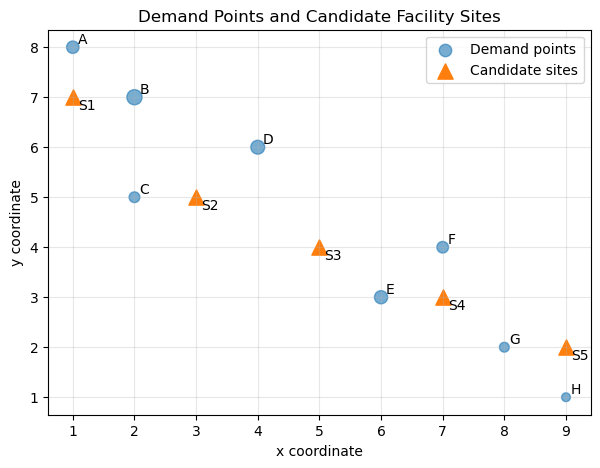

In [2]:
plt.figure(figsize=(7, 5))

plt.scatter(demand["x"], demand["y"], s=demand["weight"], alpha=0.6, label="Demand points")
plt.scatter(candidates["x"], candidates["y"], marker="^", s=120, label="Candidate sites")

for _, row in demand.iterrows():
    plt.text(row["x"] + 0.08, row["y"] + 0.08, row["name"])

for _, row in candidates.iterrows():
    plt.text(row["x"] + 0.08, row["y"] - 0.25, row["site"])

plt.title("Demand Points and Candidate Facility Sites")
plt.xlabel("x coordinate")
plt.ylabel("y coordinate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The size of each demand point represents its weight. Larger circles indicate neighborhoods with larger population. The triangles are candidate facility sites.

This figure helps us see the spatial structure before optimization. The western side has several high-weight demand points, while the eastern side has smaller but still important demand points.

---

## Compute the Distance Matrix

For this teaching example, we use Euclidean distance.


In [3]:
def euclidean_distance_matrix(demand_df, candidate_df):
    distances = np.zeros((len(demand_df), len(candidate_df)))
    
    for i, drow in demand_df.iterrows():
        for j, crow in candidate_df.iterrows():
            dx = drow["x"] - crow["x"]
            dy = drow["y"] - crow["y"]
            distances[i, j] = np.sqrt(dx**2 + dy**2)
    
    return distances

D = euclidean_distance_matrix(demand, candidates)

distance_df = pd.DataFrame(
    D,
    index=demand["name"],
    columns=candidates["site"]
)

distance_df.round(2)

site,S1,S2,S3,S4,S5
name,,,,,
A,1.00,3.61,5.66,7.81,10.00
B,1.00,2.24,4.24,6.40,8.60
C,2.24,1.00,3.16,5.39,7.62
D,3.16,1.41,2.24,4.24,6.40
E,6.40,3.61,1.41,1.00,3.16
F,6.71,4.12,2.00,1.00,2.83
G,8.60,5.83,3.61,1.41,1.00
H,10.00,7.21,5.00,2.83,1.00


The distance matrix tells us how far every demand point is from every candidate site.

In real GIS applications, this matrix may come from a road network, a travel-time API, public transit schedules, or cost-distance raster analysis. Here, we use Euclidean distance because it makes the concept easy to see.

---

## Define the p-Median Objective

For a selected set of facilities, each demand point is assigned to its nearest selected facility. The total cost is:

$$
\sum_i w_i \min_{j \in S} d_{ij}
$$

where $S$ is the set of selected facilities.


In [4]:
def evaluate_solution(selected_sites, distance_matrix, weights):
    """
    Compute total weighted distance for a selected set of candidate sites.
    
    selected_sites: tuple of candidate site indices
    distance_matrix: array with shape (number of demand points, number of candidate sites)
    weights: array of demand weights
    """
    selected_distances = distance_matrix[:, selected_sites]
    nearest_distance = selected_distances.min(axis=1)
    assigned_site_position = selected_distances.argmin(axis=1)
    
    # Convert local position inside selected_sites back to original candidate index
    assigned_sites = np.array(selected_sites)[assigned_site_position]
    
    total_cost = np.sum(weights * nearest_distance)
    
    return total_cost, nearest_distance, assigned_sites

This function is the computational version of the p-Median objective function. It does three things:

1. looks only at the selected facilities;
2. assigns each demand point to its nearest selected facility;
3. computes total weighted travel distance.

---

## Brute-Force Solver for Small p-Median Problems

For small problems, we can test every possible set of $p$ facilities.


In [5]:
def solve_p_median_bruteforce(distance_matrix, weights, p):
    n_candidates = distance_matrix.shape[1]
    best_solution = None
    best_cost = np.inf
    best_assignment = None
    best_nearest_distance = None
    
    for selected_sites in combinations(range(n_candidates), p):
        total_cost, nearest_distance, assigned_sites = evaluate_solution(
            selected_sites, distance_matrix, weights
        )
        
        if total_cost < best_cost:
            best_cost = total_cost
            best_solution = selected_sites
            best_assignment = assigned_sites
            best_nearest_distance = nearest_distance
    
    return {
        "selected_sites": best_solution,
        "total_cost": best_cost,
        "assigned_sites": best_assignment,
        "nearest_distance": best_nearest_distance
    }

weights = demand["weight"].values

result_p2 = solve_p_median_bruteforce(D, weights, p=2)

selected_site_names = candidates.iloc[list(result_p2["selected_sites"])]["site"].tolist()

selected_site_names, result_p2["total_cost"]

(['S1', 'S4'], 994.2396077753277)

This brute-force solver is transparent. It does not hide the optimization logic inside a black box.

For each possible pair of candidate sites, it computes total weighted distance. The best pair is the one with the smallest value.

For larger problems, brute-force search becomes too slow because the number of combinations grows quickly. That is why real applications often use integer programming solvers or heuristics.

---

## Inspect the Assignment Result


In [6]:
assignment_df = demand.copy()
assignment_df["assigned_site"] = candidates.iloc[result_p2["assigned_sites"]]["site"].values
assignment_df["nearest_distance"] = result_p2["nearest_distance"]
assignment_df["weighted_distance"] = assignment_df["weight"] * assignment_df["nearest_distance"]

assignment_df

,name,x,y,weight,assigned_site,nearest_distance,weighted_distance
0,A,1,8,80,S1,1.000000,80.000000
1,B,2,7,120,S1,1.000000,120.000000
2,C,2,5,60,S1,2.236068,134.164079
3,D,4,6,100,S1,3.162278,316.227766
4,E,6,3,90,S4,1.000000,90.000000
5,F,7,4,70,S4,1.000000,70.000000
6,G,8,2,50,S4,1.414214,70.710678
7,H,9,1,40,S4,2.828427,113.137085


This table shows which facility serves each demand point.

The column `nearest_distance` tells us the travel distance from each demand point to its assigned facility.

The column `weighted_distance` shows each demand point’s contribution to the objective function.

High-weight demand points can strongly influence the final solution.

---

## Visualize the p-Median Solution


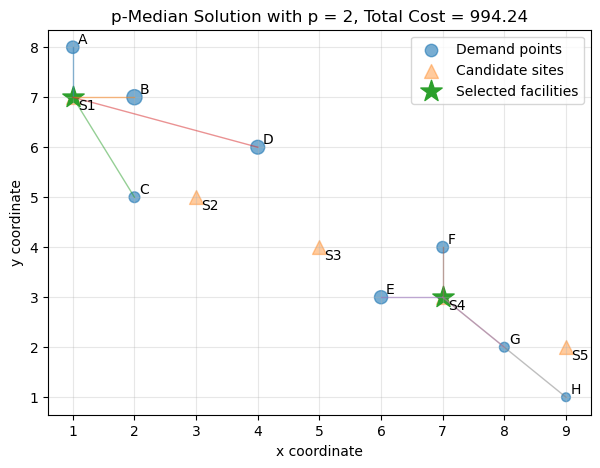

In [7]:
def plot_p_median_solution(demand_df, candidate_df, result, title):
    selected_indices = list(result["selected_sites"])
    assigned_sites = result["assigned_sites"]
    
    plt.figure(figsize=(7, 5))
    
    # Plot demand points
    plt.scatter(
        demand_df["x"], demand_df["y"],
        s=demand_df["weight"],
        alpha=0.6,
        label="Demand points"
    )
    
    # Plot all candidate sites
    plt.scatter(
        candidate_df["x"], candidate_df["y"],
        marker="^",
        s=100,
        alpha=0.4,
        label="Candidate sites"
    )
    
    # Plot selected sites
    selected = candidate_df.iloc[selected_indices]
    plt.scatter(
        selected["x"], selected["y"],
        marker="*",
        s=260,
        label="Selected facilities"
    )
    
    # Draw assignment lines
    for i, drow in demand_df.iterrows():
        assigned_idx = assigned_sites[i]
        crow = candidate_df.iloc[assigned_idx]
        plt.plot(
            [drow["x"], crow["x"]],
            [drow["y"], crow["y"]],
            linewidth=1,
            alpha=0.5
        )
    
    # Labels
    for _, row in demand_df.iterrows():
        plt.text(row["x"] + 0.08, row["y"] + 0.08, row["name"])
    
    for _, row in candidate_df.iterrows():
        plt.text(row["x"] + 0.08, row["y"] - 0.25, row["site"])
    
    plt.title(title)
    plt.xlabel("x coordinate")
    plt.ylabel("y coordinate")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_p_median_solution(
    demand,
    candidates,
    result_p2,
    title=f"p-Median Solution with p = 2, Total Cost = {result_p2['total_cost']:.2f}"
)

This figure shows three things:

1. which facilities were selected;
2. how demand points were assigned;
3. how the model reduces total weighted distance.

The assignment lines reveal the spatial logic of the model. Each demand point connects to its nearest selected facility.

---

## Sensitivity to $p$

Now let us solve the problem for different values of $p$.


In [8]:
summary = []

for p in [1, 2, 3, 4]:
    result = solve_p_median_bruteforce(D, weights, p=p)
    selected_names = candidates.iloc[list(result["selected_sites"])]["site"].tolist()
    
    summary.append({
        "p": p,
        "selected_sites": selected_names,
        "total_cost": result["total_cost"],
        "max_distance": result["nearest_distance"].max(),
        "mean_distance": result["nearest_distance"].mean()
    })

summary_df = pd.DataFrame(summary)
summary_df

,p,selected_sites,total_cost,max_distance,mean_distance
0,1,[S2],1951.302321,7.211103,3.628318
1,2,"[S1, S4]",994.239608,3.162278,1.705123
2,3,"[S1, S2, S4]",745.269119,2.828427,1.332107
3,4,"[S1, S2, S4, S5]",651.421356,1.414214,1.051777


This table shows how the solution changes as we allow more facilities.

Usually, total weighted distance decreases when $p$ increases. This makes sense: more facilities usually mean shorter travel distances. But the improvement may become smaller after a certain point. This is a diminishing returns（边际收益递减） pattern.

---

## Visualize the Sensitivity Result


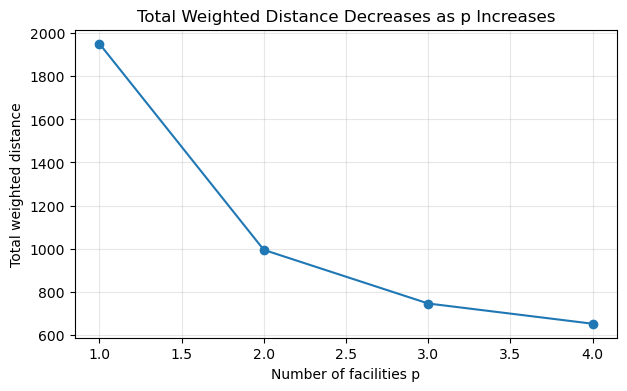

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(summary_df["p"], summary_df["total_cost"], marker="o")
plt.title("Total Weighted Distance Decreases as p Increases")
plt.xlabel("Number of facilities p")
plt.ylabel("Total weighted distance")
plt.grid(True, alpha=0.3)
plt.show()

This plot helps us ask a planning question:

> How many facilities are enough?

The p-Median model does not answer that policy question by itself. It only tells us the optimal locations for a given $p$. Choosing $p$ still requires budget, policy, and service-standard decisions.

---

## What Happens If One Demand Point Becomes More Important?

Suppose demand point H becomes much more important. Maybe it represents a vulnerable population, a growing neighborhood, or a high-risk area.

In [10]:
demand_changed = demand.copy()
demand_changed.loc[demand_changed["name"] == "H", "weight"] = 250

weights_changed = demand_changed["weight"].values

result_changed = solve_p_median_bruteforce(D, weights_changed, p=2)

selected_changed_names = candidates.iloc[list(result_changed["selected_sites"])]["site"].tolist()

selected_changed_names, result_changed["total_cost"]

(['S1', 'S5'], 1432.9867328142127)

Now compare the original and changed solutions.

In [11]:
print("Original selected sites:", selected_site_names)
print("Changed-weight selected sites:", selected_changed_names)

Original selected sites: ['S1', 'S4']
Changed-weight selected sites: ['S1', 'S5']


If the selected sites change, this shows that demand weights can strongly influence the result. If the selected sites do not change, the assignment or total cost may still change.

This is an important modeling lesson:

> p-Median is not only about geometry. It is also about how demand is weighted.

---

## How to Interpret the Results

A p-Median result should be interpreted through several outputs.

## Selected facilities

The selected facilities tell us which candidate sites minimize total weighted distance.

But they should not be interpreted as automatically “the best policy.” They are best only under the model assumptions.

### Assignment pattern

The assignment pattern tells us which demand points are served by which facility.

This can reveal service regions. In GIS, these regions may resemble catchment areas（服务区）.

### Total weighted distance

The total weighted distance is the objective value（目标函数值）. It is useful for comparing different values of $p$, different candidate site sets, or different distance metrics.

### Maximum distance

Although p-Median does not optimize maximum distance, it is still useful to report it. A solution with low average cost may still leave one community very far from service.

### Sensitivity

Sensitivity analysis（敏感性分析） is essential. You should test:

- different values of $p$;
- different demand weights;
- Euclidean distance vs network distance;
- different candidate site sets;
- inclusion or exclusion of remote demand points;
- capacity constraints if relevant.

---

## Limitations and Pathways for Improvement

The p-Median Problem is a foundational model, but it is not the end of spatial optimization. Its limitations naturally motivate later chapters.

| Limitation | Why It Matters | Possible Improvement |
|---|---|---|
| May underserve remote areas | Low-density areas may have long travel distances | p-Center, equity constraints, maximum-distance constraints |
| No capacity limit | One facility may unrealistically serve too many people | Capacitated p-Median |
| Sensitive to distance metric | Euclidean distance may misrepresent real travel | Network travel time, cost distance |
| Fixed demand | Real demand may change over time | Dynamic or stochastic models |
| Single objective | Real planning has multiple goals | Multi-objective optimization |
| Candidate sites assumed feasible | Land, zoning, cost, and politics may prevent construction | Add feasibility and cost constraints |
| No uncertainty | Travel time and demand may be uncertain | Robust or probabilistic optimization |

The most important limitation is that p-Median mainly represents **efficiency**. If a planning problem requires equity, resilience, fairness, or emergency response guarantees, then p-Median may not be enough.

This limitation leads naturally to later models:

- p-Center Problem for worst-case accessibility;
- Maximal Covering Location Problem for coverage within a threshold;
- capacitated models for realistic service limits;
- multi-objective models for balancing efficiency and equity;
- network-based models for realistic travel behavior.

---

## Common Pitfalls and Misunderstandings

## Pitfall 1: Treating Euclidean distance as real accessibility

Straight-line distance is easy to compute but may be misleading. A river, highway, mountain, or disconnected road network can make a nearby facility hard to reach.

### Pitfall 2: Forgetting demand weights

If demand weights are ignored, a neighborhood with 10 people and a neighborhood with 10,000 people may be treated equally. That may not match the planning goal.

### Pitfall 3: Thinking p-Median guarantees fairness

p-Median minimizes total weighted distance. It does not guarantee that every demand point has acceptable access.

### Pitfall 4: Over-trusting one value of $p$

The solution depends on $p$. You should compare several values and examine diminishing returns.

### Pitfall 5: Ignoring candidate site feasibility

A mathematically optimal site may not be available in the real world. Land ownership, zoning, construction cost, political boundaries, and environmental constraints matter.

### Pitfall 6: Reporting only selected locations

A good report should include selected locations, assignments, total cost, maximum distance, sensitivity analysis, limitations, and policy interpretation.

---

## Comparison with Related Methods

| Method | Main Goal | Key Question | Main Limitation | Main Trade-off |
|---|---|---|---|---|
| p-Median | Minimize total weighted distance | How do we reduce average travel cost? | May underserve remote areas | Efficient but may be inequitable |
| p-Center | Minimize maximum distance | How do we protect the worst-served demand point? | May sacrifice average efficiency | Equitable but less efficient |
| MCLP | Maximize covered demand within threshold | How many people can be served within a standard? | Sensitive to threshold choice | Good for coverage standards |
| Capacitated p-Median | Minimize distance with facility capacity | How do we assign demand without overloading facilities? | Requires capacity data | More realistic but more complex |

The key distinction is the objective function. Different objective functions represent different planning values.

- p-Median represents efficiency.
- p-Center represents worst-case equity.
- MCLP represents service coverage.
- Capacitated models represent operational realism.

---

## Practical Advice

When using p-Median in real GIS or planning research, report the following clearly:

1. **Study area:** What region is being analyzed?
2. **Demand representation:** Are demand points census centroids, buildings, parcels, grid cells, or observed events?
3. **Demand weights:** Are weights population, risk, calls, customers, or something else?
4. **Candidate sites:** Where can facilities realistically be placed?
5. **Distance metric:** Is distance Euclidean, network-based, time-based, or cost-based?
6. **Value of p:** Why was this number chosen?
7. **Objective function:** What exactly is being minimized?
8. **Solver or algorithm:** How was the model solved?
9. **Sensitivity analysis:** How stable are results under different assumptions?
10. **Limitations:** What does the model ignore?
11. **Policy interpretation:** What should decision-makers conclude, and what should they not conclude?

A strong p-Median analysis should not just say:

> These are the optimal sites.

It should say:

> These are the optimal sites under this objective, this distance metric, this demand representation, this value of $p$, and these assumptions.

That is the difference between a map and a defensible spatial optimization study.

---

## Summary

The p-Median Problem is one of the most important models in spatial optimization. It chooses $p$ facility locations to minimize total weighted travel distance from demand points to their assigned facilities.

Its core idea is simple:

$$
\text{Choose facilities so that weighted average access is as efficient as possible.}
$$

The model is powerful because it is interpretable, practical, and widely applicable. However, it has important limitations. It may underserve remote areas, ignore capacity, depend heavily on distance metrics, and optimize efficiency at the expense of equity.

A memorable way to remember p-Median is:

> p-Median finds locations that make the system efficient on average, but “average” is not always fair.

---

## Quiz

## Conceptual Questions

### Q1: What is the main goal of the p-Median Problem?

A. Minimize the maximum distance from any demand point to a facility

B. Maximize the number of demand points within a fixed coverage distance

C. Minimize total weighted distance from demand points to selected facilities

D. Minimize the number of candidate sites

<details>
<summary>Answer</summary>

Correct answer: C.

The p-Median Problem minimizes total weighted travel distance.

</details>

---

### Q2: What does $x_j = 1$ mean in the p-Median formulation?

A. Demand point $j$ has high population

B. Candidate site $j$ is selected as a facility

C. Demand point $j$ is assigned to itself

D. Facility $j$ has unlimited capacity

<details>
<summary>Answer</summary>

Correct answer: B.

The binary variable $x_j$ indicates whether candidate site $j$ is selected.

</details>

---

### Q3: Why are demand weights important?

A. They determine the number of candidate sites

B. They control the map projection

C. They make high-demand locations contribute more to the objective function

D. They remove the need for distance calculation

<details>
<summary>Answer</summary>

Correct answer: C.

A demand point with a larger weight contributes more to total weighted distance.

</details>

---

### Q4: Which limitation is most directly associated with p-Median?

A. It cannot use distance matrices

B. It may underserve remote low-weight demand points

C. It always selects remote facilities

D. It does not require candidate sites

<details>
<summary>Answer</summary>

Correct answer: B.

Because p-Median minimizes total weighted distance, remote or low-weight areas may receive poor access.

</details>

---

### Q5: Why might network travel time be better than Euclidean distance?

A. It is always smaller

B. It ignores roads

C. It better reflects actual movement through transportation networks

D. It eliminates the need for demand weights

<details>
<summary>Answer</summary>

Correct answer: C.

Network travel time often represents real accessibility more accurately than straight-line distance.

</details>

---

## Applied Questions

### Q6: Suppose one demand point has weight 100 and distance 3 to its assigned facility. What is its contribution to the p-Median objective?

<details>
<summary>Answer</summary>

The contribution is:

$$
100 \times 3 = 300
$$

So this demand point contributes 300 units to total weighted distance.

</details>

---

### Q7: Suppose $p = 2$, and the selected facilities are Site A and Site B. A demand point is distance 5 from Site A and distance 2 from Site B. Which site should it be assigned to?

<details>
<summary>Answer</summary>

It should be assigned to Site B because Site B is closer.

$$
\min(5,2)=2
$$

</details>

---

## Limitation-Oriented Question

### Q8: A p-Median model selects facilities near dense urban neighborhoods, but rural communities remain far away. Is the model wrong?

<details>
<summary>Answer</summary>

Not necessarily. The model may be correctly minimizing total weighted distance, but the objective function emphasizes average efficiency rather than equity. If rural accessibility is important, the planner may need p-Center, equity constraints, maximum-distance constraints, or a multi-objective model.

</details>

---

## Explain in Your Own Words

### Q9: Explain the difference between p-Median and p-Center in your own words.

<details>
<summary>Answer</summary>

A good answer should say that p-Median minimizes total or average weighted distance, while p-Center minimizes the worst-case distance. p-Median focuses on efficiency, while p-Center focuses more on protecting the farthest or worst-served demand point.

</details>